In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ─────────────────────────────────────────────
#  BƯỚC 1: Tiền xử lý và xây dựng Vocabulary
# ─────────────────────────────────────────────
def preprocess(text):
    text = text.lower()
    text = text.split()
    return text

def create_corpus(docs):
    processed_docs = [preprocess(doc) for doc in docs]
    # ✅ FIX BUG #1: generator expression, không phải set(word)
    vocabulary = sorted(set(word for doc in processed_docs for word in doc))
    return processed_docs, vocabulary

In [3]:
# ─────────────────────────────────────────────
#  BƯỚC 2: Term Frequency
# ─────────────────────────────────────────────
def compute_tf(word_list, vocabulary):
    word_count = {}
    for word in word_list:
        word_count[word] = word_count.get(word, 0) + 1
    tf_vector = np.array([
        word_count[word] / len(word_list) if word in word_count else 0
        for word in vocabulary
    ])
    return tf_vector

In [4]:
# ─────────────────────────────────────────────
#  BƯỚC 3: Inverse Document Frequency
# ─────────────────────────────────────────────
def compute_idf(docs, vocabulary):
    num_docs = len(docs)
    idf_vector = np.array([
        np.log((num_docs + 1) / (1 + np.sum(word in doc for doc in docs))) + 1
        for word in vocabulary
    ])
    return idf_vector

In [5]:
# ─────────────────────────────────────────────
#  BƯỚC 4: TF-IDF
# ─────────────────────────────────────────────
def compute_tf_idf(docs):
    processed_docs, vocabulary = create_corpus(docs)
    tf_matrix = np.array([compute_tf(doc, vocabulary) for doc in processed_docs])
    idf_vector = compute_idf(processed_docs, vocabulary)
    tf_idf_matrix = tf_matrix * idf_vector    # broadcasting (4,25)*(25,)
    return tf_idf_matrix

In [6]:
# ─────────────────────────────────────────────
#  BƯỚC 5: Cosine Similarity
# ─────────────────────────────────────────────
def cosine_similarity(vec1, vec2):
    dot_product = np.dot(vec1, vec2)
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    return dot_product / (norm1 * norm2) if norm1 * norm2 != 0 else 0

In [7]:
# ─────────────────────────────────────────────
#  BƯỚC 6: Check Plagiarism
# ─────────────────────────────────────────────
def check_plagiarism_all(docs):
    tf_idf_matrix = compute_tf_idf(docs)
    num_docs = len(docs)
    similarity_matrix = np.zeros((num_docs, num_docs))
    for i in range(num_docs):
        for j in range(num_docs):
            similarity_matrix[i][j] = cosine_similarity(
                tf_idf_matrix[i], tf_idf_matrix[j]
            )
    return similarity_matrix

/tmp/ipykernel_8496/2194614556.py:7: DeprecationWarning: Calling np.sum(generator) is deprecated, and in the future will give a different result. Use np.sum(np.fromiter(generator)) or the python sum builtin instead.
  np.log((num_docs + 1) / (1 + np.sum(word in doc for doc in docs))) + 1


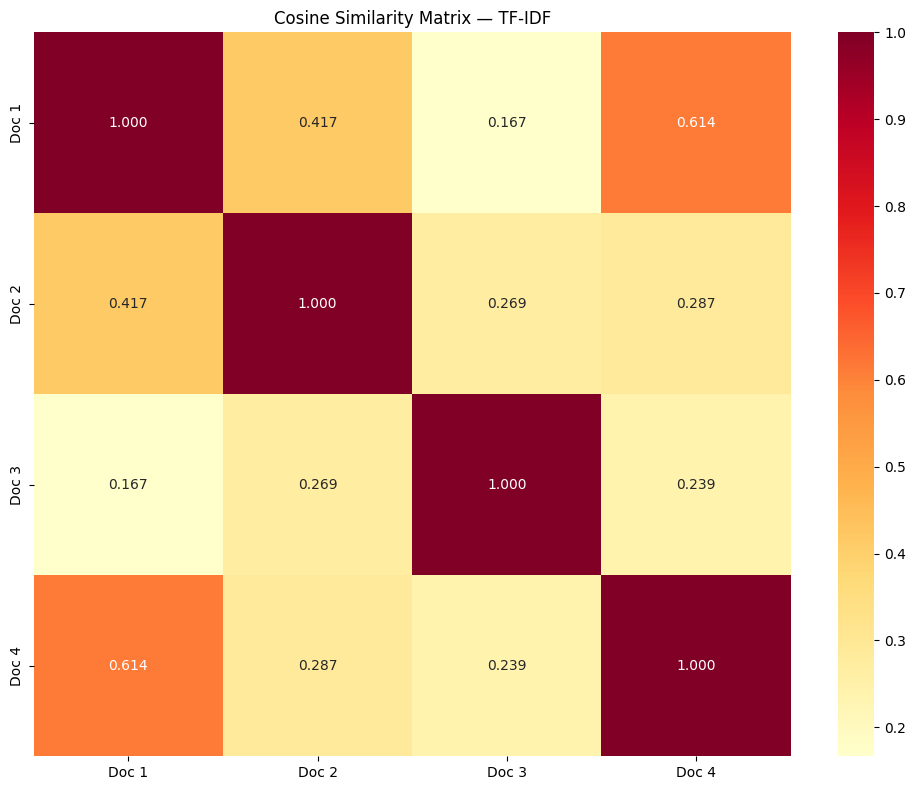

In [8]:
# ─────────────────────────────────────────────
#  CHẠY & VẼ HEATMAP
# ─────────────────────────────────────────────
docs = [
    "Học máy là một nhánh của trí tuệ nhân tạo",
    "Trí tuệ nhân tạo bao gồm học máy và mạng nơ ron",
    "Mạng nơ ron là một mô hình quan trọng trong học sâu",
    "Học sâu là một lĩnh vực của trí tuệ nhân tạo"
]

similarity_matrix = check_plagiarism_all(docs)

plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt=".3f",
            cmap="YlOrRd",
            xticklabels=[f"Doc {i+1}" for i in range(len(docs))],
            yticklabels=[f"Doc {i+1}" for i in range(len(docs))])
plt.title("Cosine Similarity Matrix — TF-IDF")
plt.tight_layout()
plt.show()